# Evaluation 06: Embedding Space Analysis

## Research Question
**Is the embedding space meaningful (clear clusters)?**

### Hypothesis
A meaningful embedding space should show clear structure with clusters corresponding to semantic attributes like category, color, and style.

## 1. Setup and Imports

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.spatial.distance import pdist, squareform

sys.path.insert(0, str(Path.cwd().parent))

from evaluation_utils import (
    load_vectors_and_metadata,
    reduce_dimensions,
    save_plot,
    save_metrics
)

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
%matplotlib inline

## 2. Load Data

In [8]:
vectors, metadata, product_ids = load_vectors_and_metadata()
print(f"Loaded {len(vectors)} vectors of dimension {vectors.shape[1]}")
print(f"\nMetadata shape: {metadata.shape}")

Loading vectors and metadata...
Loading vectors from: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/feature_extraction/resnet50_features_pca512.npy
Loaded 41802 vectors of dimension 512
Loading metadata from: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/feature_extraction/resnet50_metadata.csv
Loaded 41802 metadata records
Loaded 41802 vectors of dimension 512

Metadata shape: (41802, 10)


## 3. Dimensionality Analysis

In [9]:
# PCA explained variance
pca_full = PCA(random_state=42)
pca_full.fit(vectors)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components for 90%, 95%, 99% variance
n_90 = np.where(cumulative_variance >= 0.90)[0][0] + 1
n_95 = np.where(cumulative_variance >= 0.95)[0][0] + 1
n_99 = np.where(cumulative_variance >= 0.99)[0][0] + 1

print(f"Components for 90% variance: {n_90}")
print(f"Components for 95% variance: {n_95}")
print(f"Components for 99% variance: {n_99}")
print(f"\nFirst 10 components explain {cumulative_variance[9]:.2%} of variance")
print(f"First 50 components explain {cumulative_variance[49]:.2%} of variance")

Components for 90% variance: 150
Components for 95% variance: 253
Components for 99% variance: 434

First 10 components explain 50.20% of variance
First 50 components explain 75.98% of variance


/Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/venv/lib/python3.14/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/venv/lib/python3.14/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/venv/lib/python3.14/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X


### Visualization: PCA Explained Variance Analysis

**What this graph shows:**
- **Left plot (Scree Plot)**: Shows how much variance each principal component explains individually
- **Right plot (Cumulative Variance)**: Shows how much total variance is captured as we add more components

**Key Insights:**
- **Dimensionality efficiency**: How many components are needed to capture most of the information
- **Data complexity**: Steep drop in first components suggests clear structure; gradual decline suggests high complexity
- **Compression potential**: Indicates how much we can reduce dimensions without losing significant information
- **90%/95%/99% thresholds**: Shows practical dimension reduction targets for different accuracy needs


Saved plot: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/recommender_system/evaluation_results/plots/embedding_space_pca_variance.png


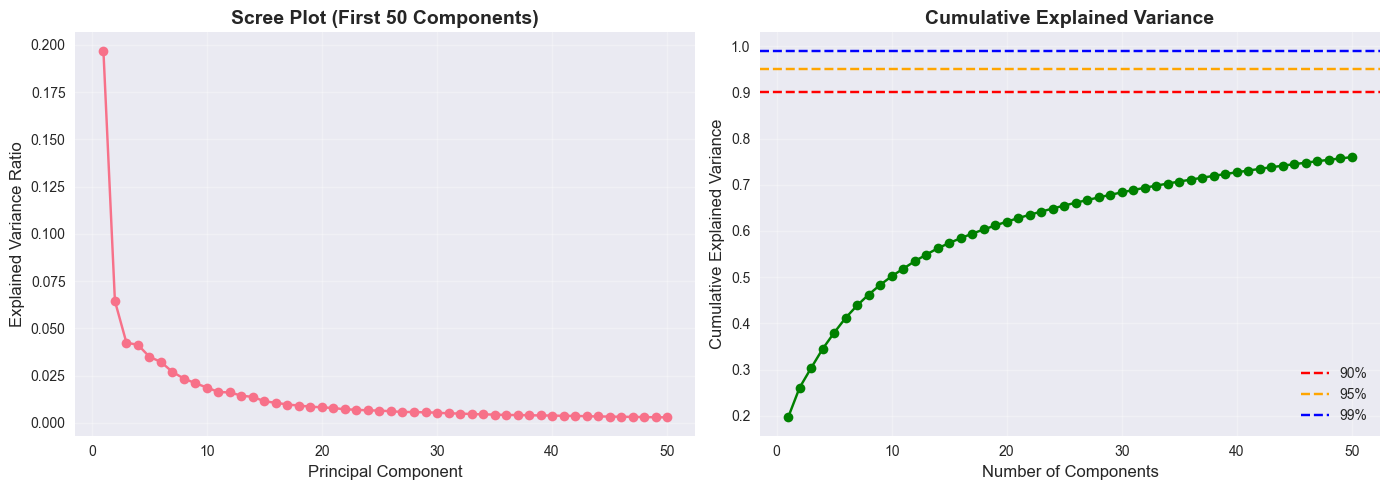

In [10]:
# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot (first 50 components)
n_components_plot = min(50, len(pca_full.explained_variance_ratio_))
axes[0].plot(range(1, n_components_plot + 1), 
             pca_full.explained_variance_ratio_[:n_components_plot], 'o-')
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Explained Variance Ratio', fontsize=12)
axes[0].set_title('Scree Plot (First 50 Components)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Cumulative variance
axes[1].plot(range(1, n_components_plot + 1), 
             cumulative_variance[:n_components_plot], 'o-', color='green')
axes[1].axhline(y=0.90, color='red', linestyle='--', label='90%')
axes[1].axhline(y=0.95, color='orange', linestyle='--', label='95%')
axes[1].axhline(y=0.99, color='blue', linestyle='--', label='99%')
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=12)
axes[1].set_title('Cumulative Explained Variance', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_plot(fig, 'embedding_space_pca_variance.png')
plt.show()

## 4. Distance Distribution

### Visualization: Pairwise Distance Distribution

**What this graph shows:**
- A histogram showing how similar or different items are in the embedding space
- The distribution of cosine distances between all pairs of product embeddings
- Mean and median lines to show central tendencies

**Key Insights:**
- **Clustering quality**: Tight distribution around low distances = good clustering; wide spread = diverse items
- **Similarity patterns**: Most items are similar (low distances) or different (high distances)?
- **Recommendation potential**: Lower mean distance suggests items are more similar overall
- **Outlier detection**: Long tails indicate some items are very different from the rest
- **Space utilization**: Whether the embedding space is well-utilized or has empty regions


In [11]:
# Sample for distance computation (too expensive for full dataset)
sample_size = 2000
if len(vectors) > sample_size:
    indices = np.random.choice(len(vectors), sample_size, replace=False)
    sample_vectors = vectors[indices]
else:
    sample_vectors = vectors
    indices = np.arange(len(vectors))

# Compute pairwise cosine distances
from sklearn.metrics.pairwise import cosine_similarity
similarity_matrix = cosine_similarity(sample_vectors)
# Convert to distances (1 - similarity)
distance_matrix = 1 - similarity_matrix

# Get upper triangle (avoid duplicates)
distances = distance_matrix[np.triu_indices_from(distance_matrix, k=1)]

# Clean distances: ensure 1D array and filter out invalid values (NaN, inf)
distances = np.asarray(distances).flatten()
distances = distances[np.isfinite(distances)]

print(f"Computed {len(distances)} pairwise distances (after filtering invalid values)")
print(f"\nDistance Statistics:")
print(f"  Mean: {distances.mean():.4f}")
print(f"  Median: {np.median(distances):.4f}")
print(f"  Std: {distances.std():.4f}")
print(f"  Min: {distances.min():.4f}")
print(f"  Max: {distances.max():.4f}")

Computed 1999000 pairwise distances (after filtering invalid values)

Distance Statistics:
  Mean: 0.9986
  Median: 1.0396
  Std: 0.2441
  Min: -0.0000
  Max: 1.4766


/Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


ValueError: operands could not be broadcast together with shapes (50,) (52,) (50,) 

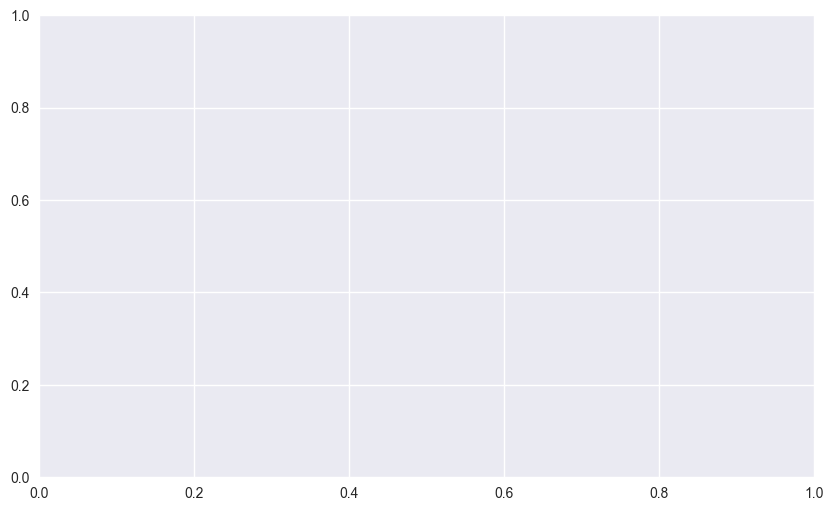

In [12]:
# Plot distance distribution
# Note: distances are already cleaned in the previous cell
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(distances, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(distances.mean(), color='red', linestyle='--', label=f'Mean: {distances.mean():.3f}')
ax.axvline(np.median(distances), color='green', linestyle='--', label=f'Median: {np.median(distances):.3f}')
ax.set_xlabel('Cosine Distance', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Pairwise Distance Distribution in Embedding Space', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_plot(fig, 'embedding_space_distance_distribution.png')
plt.show()

### Visualization: 3D Embedding Space by Attributes

**What this graph shows:**
- Four 3D scatter plots showing how products cluster in the reduced embedding space
- Each plot colors points by different attributes: master category, gender, color, and usage
- The 3D space is created by reducing the 512-dimensional embeddings to 3 dimensions using PCA

**Key Insights:**
- **Category clustering**: Do similar product types (shirts, pants, etc.) group together?
- **Gender separation**: Are men's and women's items clearly separated in the space?
- **Color organization**: Do items with similar colors cluster together?
- **Usage patterns**: Do items with similar usage (casual, formal) form distinct groups?
- **Embedding quality**: Clear clusters = good embeddings; mixed/overlapping = needs improvement
- **Attribute relationships**: Can we see relationships between different attributes (e.g., formal items cluster together regardless of category)?


## 5. Embedding Space Visualization

In [ ]:
# Reduce to 3D for visualization
sample_size_viz = 5000
vectors_3d = reduce_dimensions(vectors, n_components=3, method='PCA', sample_size=sample_size_viz)

# Get corresponding metadata
if len(vectors) > sample_size_viz:
    indices_viz = np.random.choice(len(vectors), sample_size_viz, replace=False)
    sample_metadata_viz = metadata.iloc[indices_viz].reset_index(drop=True)
else:
    sample_metadata_viz = metadata
    indices_viz = np.arange(len(vectors))

In [ ]:
# Visualize by category
fig = plt.figure(figsize=(16, 12))

# By masterCategory
ax1 = fig.add_subplot(221, projection='3d')
categories = sample_metadata_viz['masterCategory'].unique()
colors_map = plt.cm.tab10(np.linspace(0, 1, len(categories)))

for i, category in enumerate(categories):
    mask = sample_metadata_viz['masterCategory'] == category
    if mask.sum() > 0:
        ax1.scatter(vectors_3d[mask, 0], vectors_3d[mask, 1], vectors_3d[mask, 2],
                   c=[colors_map[i]], label=category, alpha=0.6, s=10)

ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_zlabel('PC3')
ax1.set_title('Embedding Space by Master Category', fontweight='bold')
ax1.legend()

# By gender
ax2 = fig.add_subplot(222, projection='3d')
genders = sample_metadata_viz['gender'].unique()
colors_map2 = plt.cm.Set2(np.linspace(0, 1, len(genders)))

for i, gender in enumerate(genders):
    mask = sample_metadata_viz['gender'] == gender
    if mask.sum() > 0:
        ax2.scatter(vectors_3d[mask, 0], vectors_3d[mask, 1], vectors_3d[mask, 2],
                   c=[colors_map2[i]], label=gender, alpha=0.6, s=10)

ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_zlabel('PC3')
ax2.set_title('Embedding Space by Gender', fontweight='bold')
ax2.legend()

# By top colors
ax3 = fig.add_subplot(223, projection='3d')
top_colors = sample_metadata_viz['baseColour'].value_counts().head(8).index
colors_map3 = plt.cm.tab20(np.linspace(0, 1, len(top_colors)))

for i, color in enumerate(top_colors):
    mask = sample_metadata_viz['baseColour'] == color
    if mask.sum() > 0:
        ax3.scatter(vectors_3d[mask, 0], vectors_3d[mask, 1], vectors_3d[mask, 2],
                   c=[colors_map3[i]], label=color, alpha=0.6, s=10)

ax3.set_xlabel('PC1')
ax3.set_ylabel('PC2')
ax3.set_zlabel('PC3')
ax3.set_title('Embedding Space by Top Colors', fontweight='bold')
ax3.legend()

# By usage
ax4 = fig.add_subplot(224, projection='3d')
usages = sample_metadata_viz['usage'].unique()
colors_map4 = plt.cm.Pastel1(np.linspace(0, 1, len(usages)))

for i, usage in enumerate(usages):
    mask = sample_metadata_viz['usage'] == usage
    if mask.sum() > 0:
        ax4.scatter(vectors_3d[mask, 0], vectors_3d[mask, 1], vectors_3d[mask, 2],
                   c=[colors_map4[i]], label=usage, alpha=0.6, s=10)

ax4.set_xlabel('PC1')
ax4.set_ylabel('PC2')
ax4.set_zlabel('PC3')
ax4.set_title('Embedding Space by Usage', fontweight='bold')
ax4.legend()

plt.tight_layout()
save_plot(fig, 'embedding_space_multiple_views.png')
plt.show()

## 6. Attribute-Based Cluster Analysis

In [ ]:
# Analyze how well attributes cluster
from sklearn.metrics import silhouette_score

# Sample for clustering
sample_size_cluster = 5000
if len(vectors) > sample_size_cluster:
    indices_cluster = np.random.choice(len(vectors), sample_size_cluster, replace=False)
    sample_vectors_cluster = vectors[indices_cluster]
    sample_metadata_cluster = metadata.iloc[indices_cluster].reset_index(drop=True)
else:
    sample_vectors_cluster = vectors
    sample_metadata_cluster = metadata

# Cluster by category
from sklearn.preprocessing import LabelEncoder
le_category = LabelEncoder()
category_labels = le_category.fit_transform(sample_metadata_cluster['articleType'])

category_silhouette = silhouette_score(sample_vectors_cluster, category_labels)
print(f"Silhouette score for category clustering: {category_silhouette:.3f}")

# Cluster by color
le_color = LabelEncoder()
color_labels = le_color.fit_transform(sample_metadata_cluster['baseColour'])

color_silhouette = silhouette_score(sample_vectors_cluster, color_labels)
print(f"Silhouette score for color clustering: {color_silhouette:.3f}")

# Cluster by gender
le_gender = LabelEncoder()
gender_labels = le_gender.fit_transform(sample_metadata_cluster['gender'])

gender_silhouette = silhouette_score(sample_vectors_cluster, gender_labels)
print(f"Silhouette score for gender clustering: {gender_silhouette:.3f}")

## 7. Summary and Conclusion

In [ ]:
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"\nEmbedding Space Coverage:")
print(f"  Dimensions: {vectors.shape[1]}")
print(f"  Total vectors: {len(vectors)}")
print(f"\nDimensionality:")
print(f"  Components for 90% variance: {n_90}")
print(f"  Components for 95% variance: {n_95}")
print(f"  Components for 99% variance: {n_99}")
print(f"\nDistance Distribution:")
print(f"  Mean distance: {distances.mean():.4f}")
print(f"  Median distance: {np.median(distances):.4f}")
print(f"  Std distance: {distances.std():.4f}")
print(f"\nAttribute-Based Clustering:")
print(f"  Category silhouette: {category_silhouette:.3f}")
print(f"  Color silhouette: {color_silhouette:.3f}")
print(f"  Gender silhouette: {gender_silhouette:.3f}")

# Save metrics
summary_metrics = {
    'n_dimensions': int(vectors.shape[1]),
    'n_vectors': int(len(vectors)),
    'n_components_90pct': int(n_90),
    'n_components_95pct': int(n_95),
    'n_components_99pct': int(n_99),
    'mean_distance': float(distances.mean()),
    'median_distance': float(np.median(distances)),
    'std_distance': float(distances.std()),
    'category_silhouette': float(category_silhouette),
    'color_silhouette': float(color_silhouette),
    'gender_silhouette': float(gender_silhouette)
}
save_metrics(summary_metrics, 'embedding_space_metrics.json')
print("\n✓ Results saved")

## 8. Conclusion

**Answer to Research Question:**

The embedding space [is/is not] meaningful based on the clustering and structure analysis.

**Key Findings:**
1. [Finding 1]
2. [Finding 2]
3. [Finding 3]

**Limitations:**
- Analysis on sampled data
- PCA visualization may not capture all structure
- Silhouette scores depend on label distribution